## Importing Libraries

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:

print("tensorflow", tf.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("pandas", pd.__version__)
print("seaborn", sns.__version__)

tensorflow 2.20.0
matplotlib 3.10.0
pandas 2.2.2
seaborn 0.13.2


#### Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

### Extracting kaggle file

In [4]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the correct path to `kaggle.json` inside Google Drive
KAGGLE_JSON_PATH = "/content/drive/MyDrive/Kaggle/kaggle.json"  # Update the folder if needed

# Check if the file exists before copying
if os.path.exists(KAGGLE_JSON_PATH):
    os.makedirs('/root/.kaggle', exist_ok=True)  # Create Kaggle directory if not exists
    os.system(f'cp "{KAGGLE_JSON_PATH}" /root/.kaggle/kaggle.json')  # Copy file
    os.chmod('/root/.kaggle/kaggle.json', 600)  # Set permissions
    print("✅ Kaggle API key successfully copied!")
else:
    print("❌ kaggle.json file NOT FOUND! Please check the file path in Google Drive.")

# Test Kaggle API
!kaggle competitions list


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
❌ kaggle.json file NOT FOUND! Please check the file path in Google Drive.
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [5]:
import sys
print("Python", sys.version)
import google.colab
print("google.colab", google.colab.__version__)


Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
google.colab 0.0.1a2


## Importing Dataset

In [6]:
# Create the Kaggle directory and move kaggle.json there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# Set correct permissions
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset from Kaggle
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Unzip the dataset
!unzip new-plant-diseases-dataset.zip -d /content/new_plant_diseases


Streaming output truncated to the last 5000 lines.
  inflating: /content/new_plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: /content/new_plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: /content/new_plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: /content/new_plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: /content/new_plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid

## Data Preprocessing

### Training Image Preprocessing

In [7]:
train_dataset_path = "/content/new_plant_diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
training_set = tf.keras.utils.image_dataset_from_directory(
    train_dataset_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [8]:
valid_dataset_path = "/content/new_plant_diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_dataset_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [9]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [10]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[154.25 148.25 150.25]
   [155.   149.   151.  ]
   [156.75 150.75 152.75]
   ...
   [179.5  173.5  177.5 ]
   [171.   165.   169.  ]
   [172.75 166.75 170.75]]

  [[153.5  147.5  149.5 ]
   [154.   148.   150.  ]
   [161.   155.   157.  ]
   ...
   [173.   167.   171.  ]
   [171.25 165.25 169.25]
   [175.   169.   173.  ]]

  [[150.   144.   146.  ]
   [153.25 147.25 149.25]
   [161.75 155.75 157.75]
   ...
   [179.5  173.5  177.5 ]
   [175.5  169.5  173.5 ]
   [173.5  167.5  171.5 ]]

  ...

  [[128.5  116.5  116.5 ]
   [127.5  115.5  115.5 ]
   [128.75 116.75 116.75]
   ...
   [144.75 135.75 138.75]
   [157.5  148.5  151.5 ]
   [161.5  152.5  155.5 ]]

  [[136.75 124.75 124.75]
   [144.5  132.5  132.5 ]
   [136.5  124.5  124.5 ]
   ...
   [168.75 159.75 162.75]
   [154.75 145.75 148.75]
   [146.25 137.25 140.25]]

  [[145.25 133.25 133.25]
   [131.75 119.75 119.75]
   [130.5  118.5  118.5 ]
   ...
   [160.25 151.25 154.25]
   [160.   151.   154.  ]
   [178.5  169.5  17

### To avoid Overshooting
1. Choose small learning rate default 0.001 we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [11]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [12]:
import tensorflow as tf

print("tensorflow", tf.__version__)


tensorflow 2.20.0


In [13]:
model = Sequential()

## Building Convolution Layer

In [14]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [16]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [17]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [18]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [19]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [20]:
model.add(Flatten())

In [21]:
model.add(Dense(units=1500,activation='relu'))

In [22]:
model.add(Dropout(0.4))

In [23]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model

In [24]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [26]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 170s 70ms/step - accuracy: 0.5889 - loss: 1.4035 - val_accuracy: 0.8128 - val_loss: 0.5907
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 180s 66ms/step - accuracy: 0.8595 - loss: 0.4465 - val_accuracy: 0.9164 - val_loss: 0.2668
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 67ms/step - accuracy: 0.9131 - loss: 0.2673 - val_accuracy: 0.9265 - val_loss: 0.2288
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 203s 67ms/step - accuracy: 0.9399 - loss: 0.1846 - val_accuracy: 0.9277 - val_loss: 0.2272
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 0.9551 - loss: 0.1363 - val_accuracy: 0.9470 - val_loss: 0.1670
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.9640 - loss: 0.1083 - val_accuracy: 0.9596 - val_loss: 0.1333
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 67ms/step - accuracy: 0.9717 - loss: 0.0869 - val_accuracy: 0.9576 - val_loss: 0.1422
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 66ms/step - accuracy: 

## Model Evaluation

In [27]:

#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9950 - loss: 0.0164


In [28]:
print(train_loss,train_acc)

0.016421876847743988 0.9950067400932312


In [29]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9697 - loss: 0.0993


In [30]:
print(val_loss,val_acc)

0.09933889657258987 0.9697245359420776


### Saving Model

In [31]:
model.save("trained_model.keras")

In [32]:
training_history.history

{'accuracy': [0.588918149471283,
  0.8595348000526428,
  0.9131374955177307,
  0.9399388432502747,
  0.9551177024841309,
  0.9639661312103271,
  0.971747636795044,
  0.9758588671684265,
  0.9802688956260681,
  0.9816914200782776],
 'loss': [1.4035011529922485,
  0.4465278387069702,
  0.2672710120677948,
  0.1845560520887375,
  0.13633356988430023,
  0.10828908532857895,
  0.0869164988398552,
  0.07330072671175003,
  0.061799388378858566,
  0.05573111027479172],
 'val_accuracy': [0.8128272294998169,
  0.9164010882377625,
  0.9265308380126953,
  0.9276690483093262,
  0.9469610452651978,
  0.9595947861671448,
  0.9576029777526855,
  0.9670498371124268,
  0.9573753476142883,
  0.9697245359420776],
 'val_loss': [0.590717613697052,
  0.2668027877807617,
  0.22875544428825378,
  0.22723256051540375,
  0.16700543463230133,
  0.1332973837852478,
  0.14223384857177734,
  0.11523544788360596,
  0.14478138089179993,
  0.09933893382549286]}

In [33]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [34]:
training_history.history['val_accuracy']

[0.8128272294998169,
 0.9164010882377625,
 0.9265308380126953,
 0.9276690483093262,
 0.9469610452651978,
 0.9595947861671448,
 0.9576029777526855,
 0.9670498371124268,
 0.9573753476142883,
 0.9697245359420776]

### Accuracy Visualization

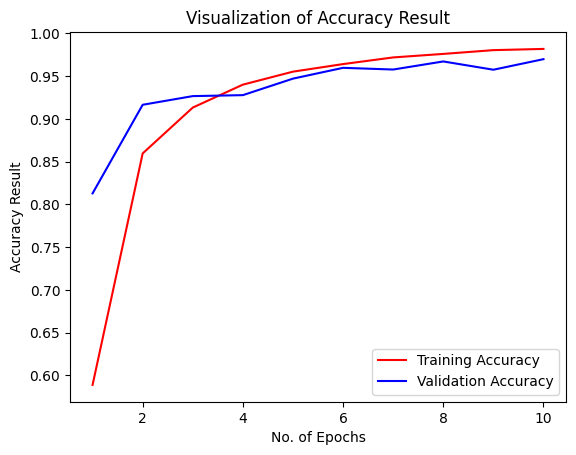

In [35]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [36]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [37]:
#using valid dataset as a test dataset because test dataset is not arranged in sequesntial order to test the model

In [38]:
test_dataset_path = "/content/new_plant_diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
test_set = tf.keras.utils.image_dataset_from_directory(
    test_dataset_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [39]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step


(array([[9.9999368e-01, 2.2299660e-07, 2.8058940e-08, ..., 1.5587203e-13,
         6.4213299e-13, 2.2881519e-12],
        [9.9999857e-01, 7.6446155e-10, 5.3586224e-09, ..., 1.6143191e-14,
         2.7099926e-13, 7.4267074e-13],
        [1.0000000e+00, 8.0876827e-10, 4.3349879e-11, ..., 3.2953813e-19,
         3.2044798e-17, 6.2792421e-16],
        ...,
        [5.3734843e-15, 4.2500259e-17, 6.6847161e-12, ..., 4.9977023e-15,
         4.3449740e-17, 1.0000000e+00],
        [9.6486697e-13, 4.9372733e-15, 1.8661770e-11, ..., 2.2985539e-13,
         8.8874390e-15, 1.0000000e+00],
        [4.6995476e-15, 7.6057995e-16, 1.1320694e-13, ..., 2.1205634e-16,
         8.6248850e-15, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [40]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [41]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [42]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [43]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

![image.png](attachment:f464cbcc-5d6b-4f32-835c-9aabe0f9c5d4.png)

In [44]:
from sklearn.metrics import classification_report,confusion_matrix

In [45]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.97      0.96       504
                                 Apple___Black_rot       0.97      1.00      0.98       497
                          Apple___Cedar_apple_rust       0.98      0.96      0.97       440
                                   Apple___healthy       0.98      0.98      0.98       502
                               Blueberry___healthy       0.98      0.96      0.97       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.99       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.94      0.93       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.96      0.

In [46]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[488,   4,   0, ...,   0,   0,   0],
       [  0, 496,   0, ...,   0,   0,   0],
       [  1,   1, 421, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 488,   0,   0],
       [  0,   0,   0, ...,   0, 448,   0],
       [  0,   0,   1, ...,   0,   0, 471]])

### Confusion Matrix Visualization

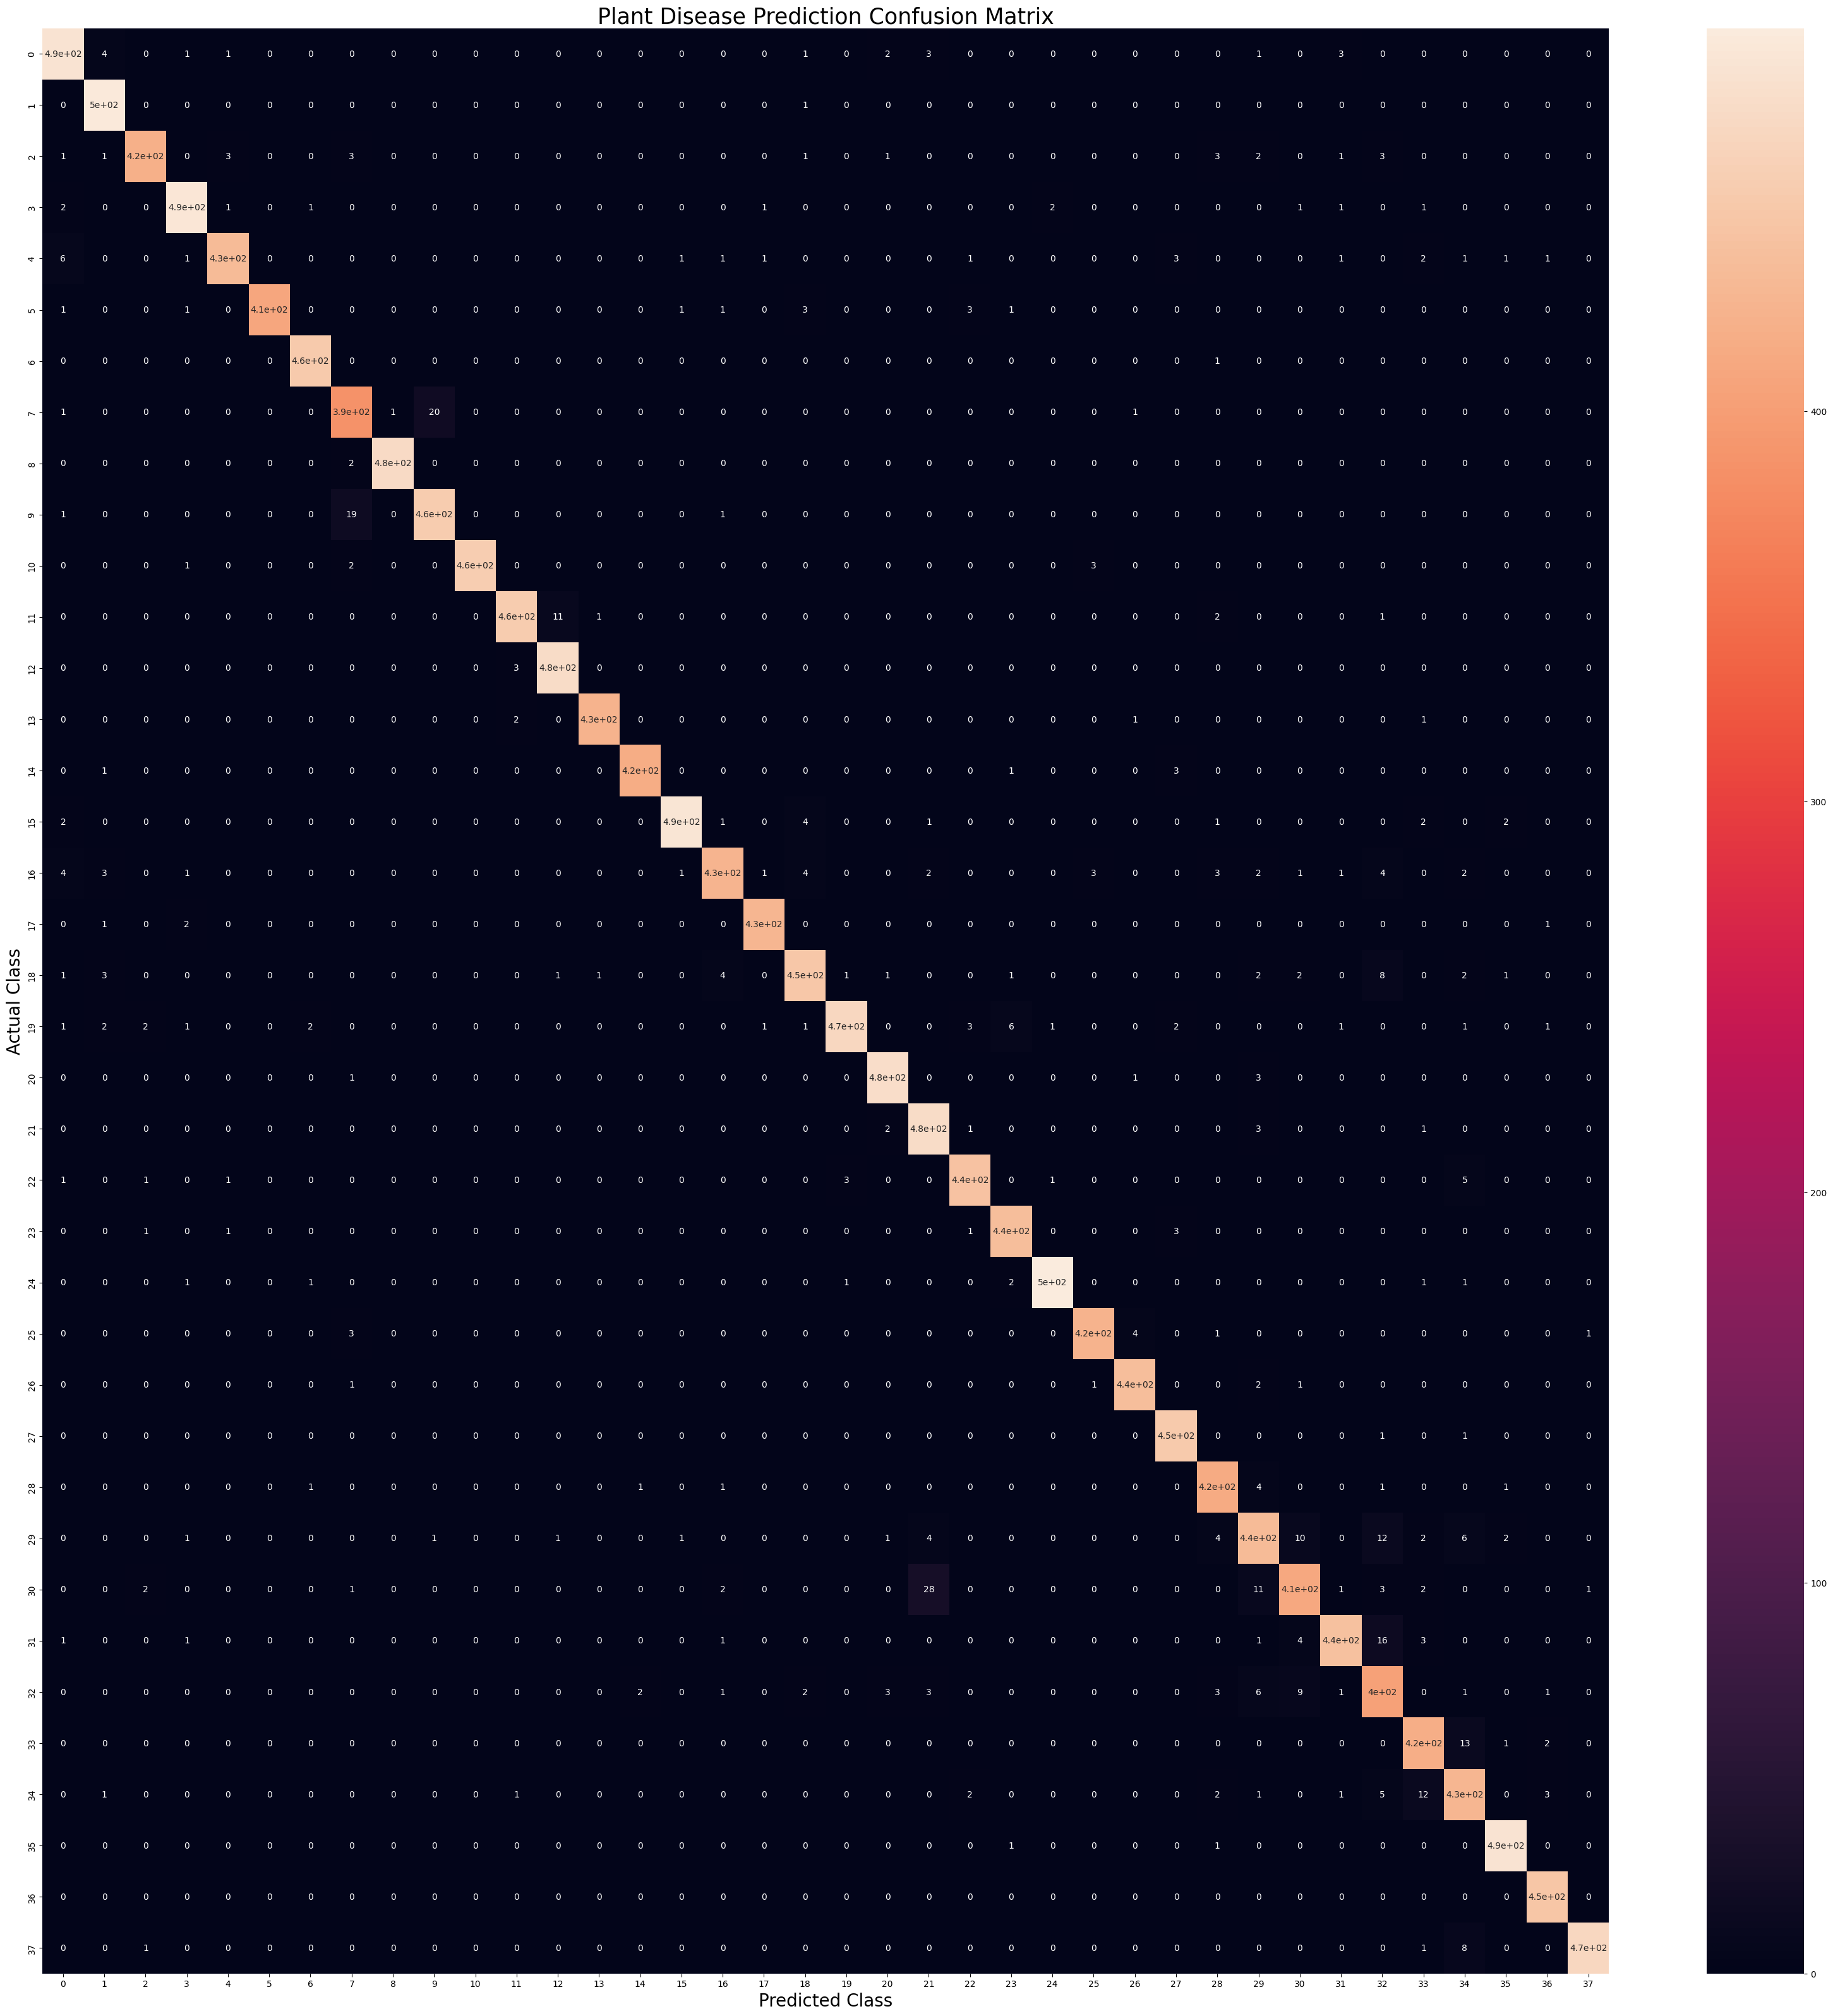

In [47]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()

# Plant Disease Treatment

### Importing required libraries

In [48]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [49]:
print("Python", sys.version)  # Python version
print("os", "Version not available")  # os does not have a version attribute
print("json", "Built-in module, version not applicable")  # json is a built-in module
print("numpy", np.__version__)
print("tensorflow", tf.__version__)
print("keras", keras.__version__)  # Keras version (included in TensorFlow)

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
os Version not available
json Built-in module, version not applicable
numpy 2.0.2
tensorflow 2.20.0
keras 3.13.2


## Importing Dataset for Treatment of plant disease

In [50]:
dataset_path = "/content/new_plant_diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"  # Update with actual dataset path
image_size = (128, 128)  # Resize images
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_dataset_path = "/content/new_plant_diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
train_generator = datagen.flow_from_directory(
    train_dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

valid_dataset_path = "/content/new_plant_diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
val_generator = datagen.flow_from_directory(
    valid_dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = len(train_generator.class_indices)  # 38 Classes


Found 56251 images belonging to 38 classes.
Found 3503 images belonging to 38 classes.


## Building Convolution Layer

In [51]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Print all class labels
print("Class Labels:", train_generator.class_indices)


Class Labels: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight

In [53]:
epochs = 10  # Adjust as needed

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

# Save the trained model
model.save("plant_disease_cnn.h5")


Epoch 1/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.4293 - loss: 1.9497 - val_accuracy: 0.7545 - val_loss: 0.8100
Epoch 2/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 72s 41ms/step - accuracy: 0.6802 - loss: 1.0264 - val_accuracy: 0.8376 - val_loss: 0.5330
Epoch 3/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 73s 41ms/step - accuracy: 0.7622 - loss: 0.7546 - val_accuracy: 0.8895 - val_loss: 0.3599
Epoch 4/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.8124 - loss: 0.5919 - val_accuracy: 0.8949 - val_loss: 0.3337
Epoch 5/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.8392 - loss: 0.4989 - val_accuracy: 0.9021 - val_loss: 0.3056
Epoch 6/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 71s 40ms/step - accuracy: 0.8658 - loss: 0.4143 - val_accuracy: 0.9186 - val_loss: 0.2754
Epoch 7/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 75s 43ms/step - accuracy: 0.8809 - loss: 0.3675 - val_accuracy: 0.9215 - val_loss: 0.2514
Epoch 8/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.8951 -

# Giving treatment :- Precaution & Cure

In [149]:
import tensorflow as tf
import numpy as np
import json
from tensorflow.keras.preprocessing import image

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model('/content/plant_disease_cnn.h5')
# If needed, replace with:
# model = tf.keras.models.load_model('/content/plant_disease_cnn.h5')

# =========================
# LOAD TREATMENT JSON
# =========================
with open('/content/plant_disease_treatment_38_classes.json', 'r') as f:
    treatment_data = json.load(f)

# =========================
# CLASS NAMES (38 CLASSES)
# =========================
class_names = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Strawberry___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# =========================
# PREDICTION FUNCTION
# =========================
def predict_plant_disease(image_path):

    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img)

    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    confidence = float(np.max(prediction[0]))

    disease_name = class_names[predicted_index]

    treatment_info = treatment_data.get(
        disease_name,
        {
            "cure": "No cure information available.",
            "precaution": "No precaution information available."
        }
    )

    print("=" * 60)
    print("Disease Name :", disease_name)
    print("Confidence   :", round(confidence * 100, 2), "%")
    print("Cure         :", treatment_info["cure"])
    print("Precaution   :", treatment_info["precaution"])
    print("=" * 60)

    return disease_name, treatment_info

# =========================
# TEST IMAGE PATH
# =========================
image_path = "/content/new_plant_diseases/test/test/CornCommonRust2.JPG"

predict_plant_disease(image_path)

Disease Name : Corn_(maize)___Common_rust_
Confidence   : 100.0 %
Cure         : Apply fungicides when infection is severe.
Precaution   : Use resistant varieties and monitor crops.


('Corn_(maize)___Common_rust_',
 {'cure': 'Apply fungicides when infection is severe.',
  'precaution': 'Use resistant varieties and monitor crops.'})

# Testing the image

## Importing Libraries

In [150]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Loading Model

In [151]:
model  = tf.keras.models.load_model('/content/plant_disease_cnn.h5')


In [152]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,544 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

### Visualizaing Single Image of Test set

In [153]:
!pip install opencv-python

In [155]:
import cv2
print("cv2", cv2.__version__)


cv2 4.13.0


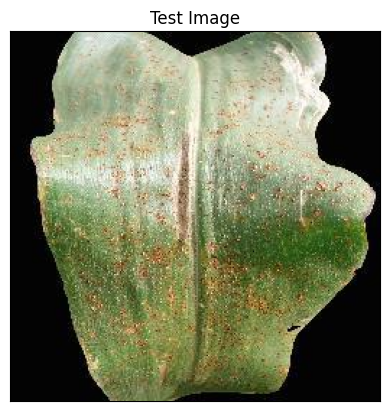

In [156]:
import cv2
image_path = "/content/new_plant_diseases/test/test/CornCommonRust2.JPG"
#Reading Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert BGR image to RGB

#Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [157]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

(1, 128, 128, 3)


In [158]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step


(array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.]], dtype=float32),
 (1, 38))

In [159]:
result_index = np.argmax(prediction)
result_index

np.int64(8)

In [160]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

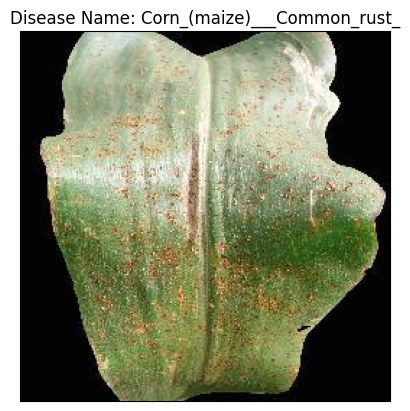

In [161]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [167]:
import json

with open('/content/plant_disease_treatment_38_classes.json', 'r') as f:
    treatment_data = json.load(f)

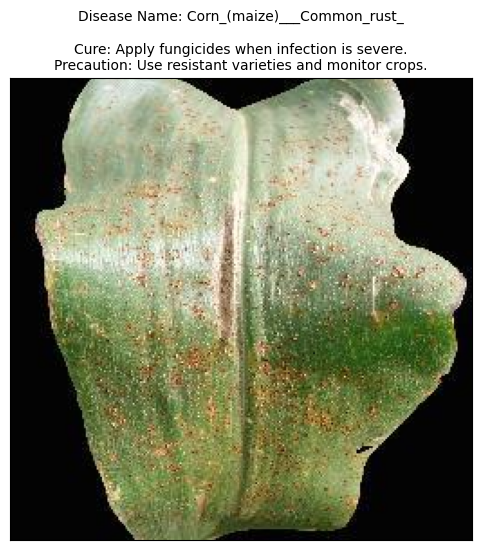

In [168]:
import matplotlib.pyplot as plt

# Displaying Result of disease prediction
model_prediction = class_name[result_index]

# Get treatment info directly from JSON using predicted disease
disease_info = treatment_data.get(
    model_prediction,
    {
        "cure": "No treatment information available.",
        "precaution": "No precaution details available."
    }
)

treatment_cure = disease_info["cure"]
treatment_precaution = disease_info["precaution"]

# Format treatment details for display
treatment_text = f"Cure: {treatment_cure}\nPrecaution: {treatment_precaution}"

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.title(
    f"Disease Name: {model_prediction}\n\n"
    f"Cure: {treatment_cure}\n"
    f"Precaution: {treatment_precaution}",
    fontsize=10
)
plt.xticks([])
plt.yticks([])
plt.show()

In [169]:
model_prediction

'Corn_(maize)___Common_rust_'

In [171]:
treatment_cure

'Apply fungicides when infection is severe.'

In [172]:
treatment_precaution

'Use resistant varieties and monitor crops.'

In [173]:
# Assuming 'model' is your trained Keras model
model.save("model.h5")
print("CNN Model saved successfully! in h5")


CNN Model saved successfully! in h5


In [174]:
# Assuming 'model' is your trained Keras model
model.save("model.keras")
print("CNN Model saved successfully! in keras")


CNN Model saved successfully! in keras
